# 🌡️ EDA & Prediksi Data Cuaca IoT

**Mata Kuliah:** Kecerdasan Buatan  
**Deskripsi:** Analisis data time series dari sensor IoT (suhu, kelembapan, cahaya) yang diambil setiap 5 menit dan disimpan ke Google Sheets.

---

### 📋 Alur:
1. Import Library
2. Load & Inspect Data
3. Preprocessing (parsing, konversi tipe data)
4. Deteksi & Handling Missing Values (akibat jaringan down)
5. Feature Engineering (jam, hari, flag cahaya artifisial)
6. EDA — Univariat, Bivariat, Multivariat
7. Deteksi Outlier
8. Prediksi Suhu (Regresi Linear & ARIMA sederhana)
9. Kesimpulan


# 1. Import Library

> **Daftar Library**  
> - `pandas` & `numpy`: manipulasi data tabular  
> - `matplotlib` & `seaborn`: visualisasi statis  
> - `plotly`: visualisasi interaktif (bagus untuk time series!)  
> - `statsmodels`: untuk ARIMA (prediksi time series)  
> - `sklearn`: untuk regresi linear  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!




---



# 2. Load & Inspect Data

In [2]:
# Load data
df_raw = pd.read_csv('DataCuaca-Data-1.csv')

print(f'Shape data: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom')
print()
df_raw.head(10)

Shape data: 328 baris × 5 kolom



,timestamp,suhu,kelembapan,cahaya,kondisi
0,"25/3/2026, 11.32.23","38,54","58,13",1737,TERANG
1,"25/3/2026, 11.37.37","38,13","60,36",1731,TERANG
2,"25/3/2026, 11.44.03","37,79","60,92",1562,TERANG
3,"25/3/2026, 11.49.08","37,91","60,25",1699,TERANG
4,"25/3/2026, 11.54.11","39,09","56,51",1420,TERANG
5,"25/3/2026, 11.59.14","39,5","55,23",1501,TERANG
6,"25/3/2026, 12.04.20","39,52","54,14",1593,TERANG
7,"25/3/2026, 12.09.22","39,5","54,02",1430,TERANG
8,"25/3/2026, 12.14.26","39,5",54,1498,TERANG
9,"25/3/2026, 12.19.29","39,5",54,1560,TERANG


In [3]:
# Cek tipe data & nilai awal
print('=== INFO KOLOM ===')
df_raw.info()
print()

print('=== SAMPEL NILAI KOLOM ===')
for col in df_raw.columns:
    print(f'{col}: {df_raw[col].iloc[0]!r}  →  tipe: {df_raw[col].dtype}')

=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   timestamp   328 non-null    object
 1   suhu        328 non-null    object
 2   kelembapan  328 non-null    object
 3   cahaya      328 non-null    int64 
 4   kondisi     328 non-null    object
dtypes: int64(1), object(4)
memory usage: 12.9+ KB

=== SAMPEL NILAI KOLOM ===
timestamp: '25/3/2026, 11.32.23'  →  tipe: object
suhu: '38,54'  →  tipe: object
kelembapan: '58,13'  →  tipe: object
cahaya: np.int64(1737)  →  tipe: int64
kondisi: 'TERANG'  →  tipe: object




---



# 3. Prepocessing

> Hal yang perlu dilakukan sebelum data diolah:
> 1. Konversi timestamp ke format datetime agar bisa dianalisis secara temporal
> 2. Konversi desimal koma → titik agar Python bisa membacanya sebagai angka
> 3. Urutkan data berdasarkan waktu (time series harus terurut)

In [4]:
df = df_raw.copy()  # Selalu kerja di copy, bukan data asli!

# 3.1 Parse timestamp
# Format asli: '25/3/2026, 11.32.23'  →  titik di jam perlu jadi titik dua
df['timestamp'] = df['timestamp'].str.replace(
    r'(\d+)\.(\d+)\.(\d+)$',  # pola: angka.angka.angka di akhir
    r'\1:\2:\3',               # ganti jadi angka:angka:angka
    regex=True
)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y, %H:%M:%S', errors='coerce')

#  3.2 Konversi desimal koma → titik
df['suhu']       = df['suhu'].astype(str).str.replace(',', '.').astype(float)
df['kelembapan'] = df['kelembapan'].astype(str).str.replace(',', '.').astype(float)

#  3.3 Urutkan berdasarkan waktu & reset index
df = df.sort_values('timestamp').reset_index(drop=True)

#  3.4 Set timestamp sebagai index (standar time series)
df = df.set_index('timestamp')

print('✅ Preprocessing selesai!')
print(f'Rentang waktu: {df.index.min()}  →  {df.index.max()}')
print(f'Durasi total : {df.index.max() - df.index.min()}')
print()
print(df.dtypes)
print()
df.head()

✅ Preprocessing selesai!
Rentang waktu: 2026-03-25 11:32:23  →  2026-03-27 14:38:44
Durasi total : 2 days 03:06:21

suhu          float64
kelembapan    float64
cahaya          int64
kondisi        object
dtype: object



,suhu,kelembapan,cahaya,kondisi
timestamp,,,,
2026-03-25 11:32:23,38.54,58.13,1737,TERANG
2026-03-25 11:37:37,38.13,60.36,1731,TERANG
2026-03-25 11:44:03,37.79,60.92,1562,TERANG
2026-03-25 11:49:08,37.91,60.25,1699,TERANG
2026-03-25 11:54:11,39.09,56.51,1420,TERANG




---



## 4. Deteksi & Handling Missing Values

> **Konteks masalah:**  
> Sensor seharusnya merekam data setiap **5 menit**. Namun karena jaringan internet kadang down, ada periode waktu di mana data tidak tersimpan → timbul **gap** di time series.
>
> **Strategi:**
> - Buat timeline lengkap setiap 5 menit (reindex)
> - Tandai baris yang hilang
> - Isi dengan **interpolasi linear** (cocok untuk suhu & kelembapan yang berubah gradual)
> - Cahaya diisi dengan `forward fill` (nilai terakhir) karena perubahan cahaya bisa tiba-tiba

Total gap > 10 menit: 49 kejadian
Total menit data yang hilang: 1646 menit (~27.4 jam)



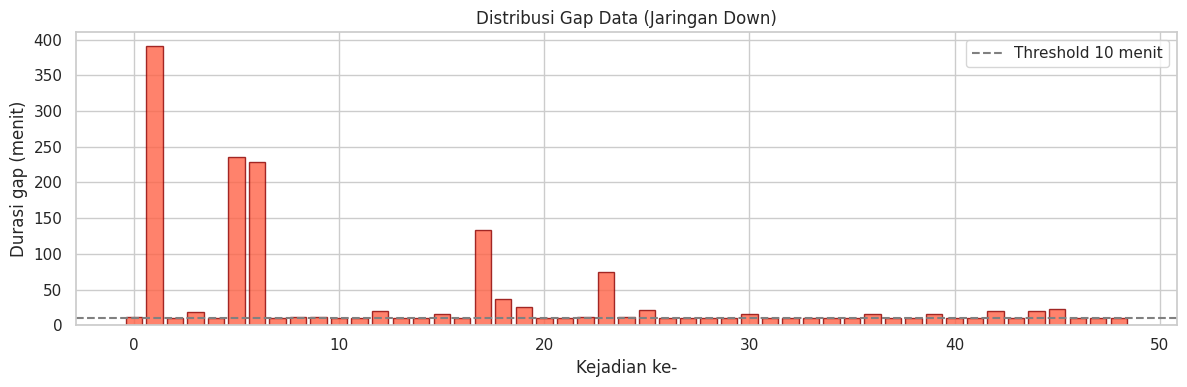

Gap terbesar:
          timestamp  gap_menit
2026-03-25 19:17:22 390.600000
2026-03-26 00:34:59 235.450000
2026-03-26 06:20:17 229.016667
2026-03-26 18:53:16 132.750000
2026-03-26 22:04:15  74.033333


In [5]:
# 4.1 Cek gap di data asli
df_temp = df.reset_index()
df_temp['gap_menit'] = df_temp['timestamp'].diff().dt.total_seconds() / 60

big_gaps = df_temp[df_temp['gap_menit'] > 10][['timestamp', 'gap_menit']]
print(f'Total gap > 10 menit: {len(big_gaps)} kejadian')
print(f'Total menit data yang hilang: {big_gaps["gap_menit"].sum():.0f} menit'
      f' (~{big_gaps["gap_menit"].sum()/60:.1f} jam)')
print()

# Tampilkan distribusi gap
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(big_gaps)), big_gaps['gap_menit'].values, color='tomato', edgecolor='darkred', alpha=0.8)
ax.axhline(y=10, color='gray', linestyle='--', label='Threshold 10 menit')
ax.set_xlabel('Kejadian ke-')
ax.set_ylabel('Durasi gap (menit)')
ax.set_title('Distribusi Gap Data (Jaringan Down)')
ax.legend()
plt.tight_layout()
plt.show()

print('Gap terbesar:')
print(big_gaps.nlargest(5, 'gap_menit').to_string(index=False))

In [15]:
# Pastikan timestamp sudah jadi index datetime
print("Sebelum set_index:")
print(df.dtypes)
print(df.head(2))

Sebelum set_index:
suhu          float64
kelembapan    float64
cahaya          int64
kondisi        object
dtype: object
                      suhu  kelembapan  cahaya kondisi
timestamp                                             
2026-03-25 11:32:23  38.54       58.13    1737  TERANG
2026-03-25 11:37:37  38.13       60.36    1731  TERANG


In [17]:
# 4.2 Reindex ke 5 menit penuh & tandai mana yang asli / imputasi
start    = df.index.min().floor('5min')
end      = df.index.max().ceil('5min')
full_idx = pd.date_range(start=start, end=end, freq='5min')
df_full  = df.reindex(full_idx, method='nearest', tolerance=pd.Timedelta('3min'))
df_full.index.name = 'timestamp'

# Buat flag: True = data asli, False = akan diimputasi
df_full['is_original'] = ~df_full['suhu'].isna()

n_missing = df_full['suhu'].isna().sum()
print(f'Total timestep setelah reindex : {len(df_full)}')
print(f'Data asli                      : {df_full["is_original"].sum()}')
print(f'Baris yang perlu diisi         : {n_missing} ({n_missing/len(df_full)*100:.1f}%)')

Total timestep setelah reindex : 615
Data asli                      : 344
Baris yang perlu diisi         : 271 (44.1%)


✅ Imputasi selesai. Missing values tersisa: 0


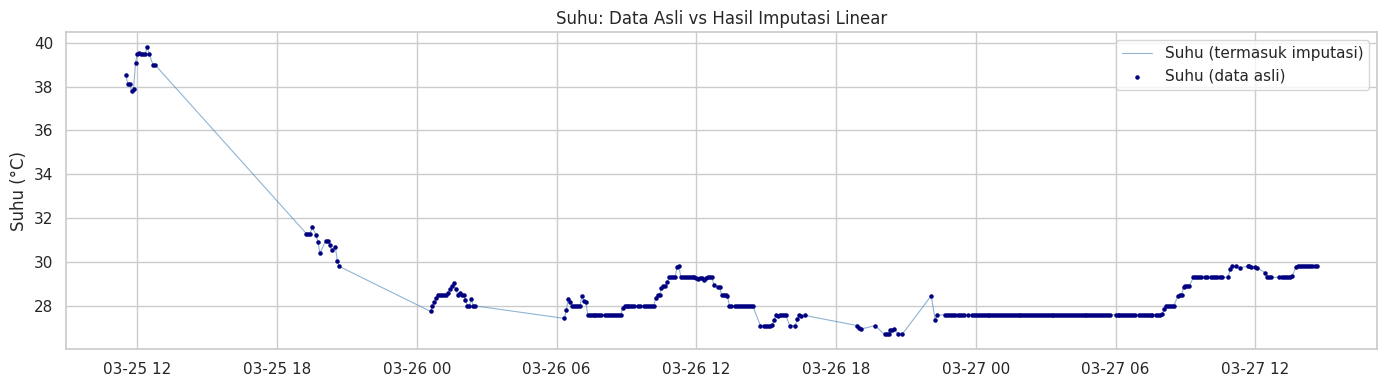

In [19]:
# 4.3 Imputasi
# Suhu & kelembapan: interpolasi linear
df_full['suhu']       = df_full['suhu'].interpolate(method='linear')
df_full['kelembapan'] = df_full['kelembapan'].interpolate(method='linear')

# Cahaya: forward fill
df_full['cahaya']  = df_full['cahaya'].ffill()

# Kondisi: forward fill
df_full['kondisi'] = df_full['kondisi'].ffill()

print(f'✅ Imputasi selesai. Missing values tersisa: {df_full[["suhu","kelembapan","cahaya"]].isna().sum().sum()}')

# Visualisasi
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_full.index, df_full['suhu'], color='steelblue', alpha=0.6, linewidth=0.8, label='Suhu (termasuk imputasi)')

# Ambil data asli dari df_full yang is_original == True
df_asli = df_full[df_full['is_original'] == True]
ax.scatter(df_asli.index, df_asli['suhu'],
           color='navy', s=5, zorder=5, label='Suhu (data asli)')

ax.set_title('Suhu: Data Asli vs Hasil Imputasi Linear')
ax.set_ylabel(f'Suhu (\u00b0C)')
ax.legend()
plt.tight_layout()
plt.show()



---



# 5. Feature Engineering

Model prediksi tidak bisa langsung memahami kolom `timestamp`. Perlu mengekstrak informasi temporal menjadi kolom numerik yang bisa dipelajari model.

**Fitur tambahan:**
*   `jam`, `menit`, `hari_ke`, `minggu_ke`: informasi waktu
*   `is_malam`: apakah sedang malam hari (21:00-05:59)
*   `cahaya_artifisial`: flag cahaya yang tinggi padahal malam (lampu kamar nyala)

In [20]:
df_feat = df_full.copy()

# Ekstrasi waktu
df_feat['jam']          = df_feat.index.hour
df_feat['menit']        = df_feat.index.minute
df_feat['hari_minggu']  = df_feat.index.dayofweek     # 0 = senin, 6 = minggu
df_feat['hari_ke']      = (df_feat.index - df_feat.index.min()).total_seconds() / 86400

# flag malam (21:00 - 05:59)
df_feat['is_malam'] = df_feat['jam'].apply(lambda h: 1 if h>= 21 or h < 6 else 0)

# threshold cahaya: nilai > 2000 dianggap 'cukup terang'
# cahaya artifisial = malam tapi cahaya tinggi (lampu kamar nyala)
THRESHOLD_CAHAYA = 2000
df_feat['cahaya_artifisial'] = ((df_feat['is_malam'] == 1) &
                                (df_feat['cahaya'] > THRESHOLD_CAHAYA)).astype(int)

n_artifisial = df_feat['cahaya_artifisial'].sum()
print(f'✅ Feature engineering done')
print(f'Terdeteksi {n_artifisial} timestemp ({n_artifisial*5/60:.1f} jam) cahaya artifisial malam')
print()
df_feat.head(3)

✅ Feature engineering done
Terdeteksi 216 timestemp (18.0 jam) cahaya artifisial malam



,suhu,kelembapan,cahaya,kondisi,is_original,jam,menit,hari_minggu,hari_ke,is_malam,cahaya_artifisial
timestamp,,,,,,,,,,,
2026-03-25 11:30:00,38.54,58.13,1737.0,TERANG,True,11,30,2,0.000000,0,0
2026-03-25 11:35:00,38.13,60.36,1731.0,TERANG,True,11,35,2,0.003472,0,0
2026-03-25 11:40:00,38.13,60.36,1731.0,TERANG,True,11,40,2,0.006944,0,0


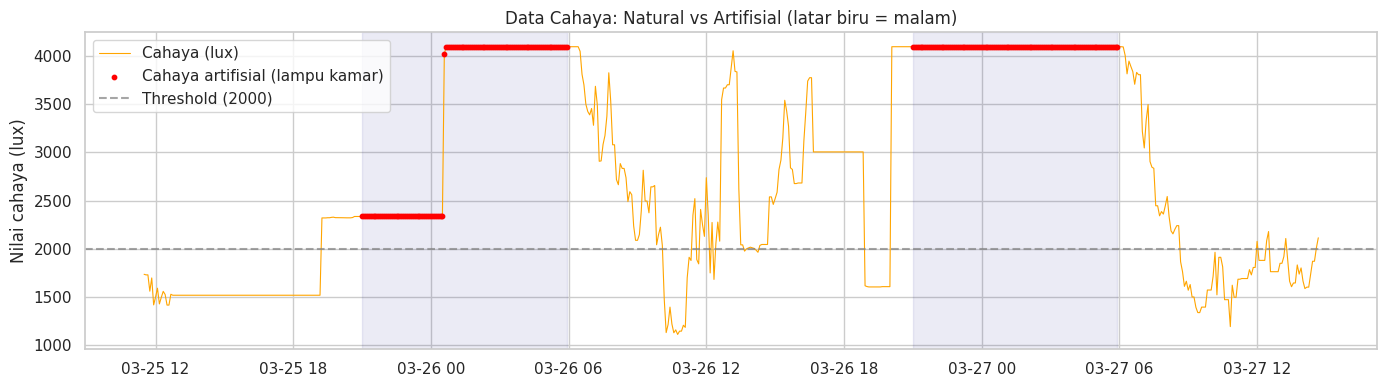

In [21]:
# visualisasi cahaya artifisial
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(df_feat.index, df_feat['cahaya'], color='orange', linewidth=0.8, label='Cahaya (lux)')

# shading area malam
for i, row in df_feat[df_feat['is_malam'] == 1].groupby((df_feat['is_malam'].diff() != 0).cumsum()):
  ax.axvspan(row.index[0], row.index[-1], alpha=0.08, color='navy')

# mark cahaya artifisial
mask_art = df_feat['cahaya_artifisial'] == 1
ax.scatter(df_feat[mask_art].index, df_feat[mask_art]['cahaya'],
           color='red', s=10, zorder=5, label='Cahaya artifisial (lampu kamar)')

ax.axhline(y=THRESHOLD_CAHAYA, color='gray', linestyle='--', alpha=0.7, label=f'Threshold ({THRESHOLD_CAHAYA})')
ax.set_title('Data Cahaya: Natural vs Artifisial (latar biru = malam)')
ax.set_ylabel('Nilai cahaya (lux)')
ax.legend()
plt.tight_layout()
plt.show()



---



## 6. EDA (Exploratory Data Analysis)

### 6.1 Statistik Deskriptif

In [22]:
cols_sensor = ['suhu', 'kelembapan', 'cahaya']
print('=== STATISTIK DESKRIPTIF ===')
df_feat[cols_sensor].describe().round(2)

df shape: (328, 4)
df_full shape: (615, 5)
df_feat shape: (615, 11)

df suhu nunique: 96
df_full suhu nunique: 343
df_feat suhu nunique: 343

df_feat head:
                       suhu  kelembapan  cahaya
timestamp                                     
2026-03-25 11:30:00  38.54       58.13  1737.0
2026-03-25 11:35:00  38.13       60.36  1731.0
2026-03-25 11:40:00  38.13       60.36  1731.0
2026-03-25 11:45:00  37.79       60.92  1562.0
2026-03-25 11:50:00  37.91       60.25  1699.0
2026-03-25 11:55:00  39.09       56.51  1420.0
2026-03-25 12:00:00  39.50       55.23  1501.0
2026-03-25 12:05:00  39.52       54.14  1593.0
2026-03-25 12:10:00  39.50       54.02  1430.0
2026-03-25 12:15:00  39.50       54.00  1498.0
=== STATISTIK DESKRIPTIF ===


,suhu,kelembapan,cahaya
count,615.00,615.00,615.00
mean,29.36,87.48,2782.52
std,3.02,11.27,1059.83
min,26.70,53.09,1114.00
25%,27.60,85.44,1700.00
50%,28.00,92.00,2447.00
75%,29.39,93.97,4095.00
max,39.82,97.99,4095.00


### 6.2 Analisis Univariat - Distribuasi Tiap Variable

Melihat **distribusi nilai** masing-masing sensor. Histogram menunjukkan seberapa sering niali muncul. KDE (Kernel Density Estimate) menunjukkan kurva distribusinya.